# ERA5 Land Data
ERA5 data extraction notebook.


In [ ]:
import ee
import os
import datetime
import re
import glob
import pandas as pd

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Authenticate and initialize ----------------------------------------------------------------------
ee.Authenticate()
ee.Initialize(project='fire-seasons')

## Configurations

In [16]:
# Imports and configurations -----------------------------------------------------------------------

YEARS = range(2002, 2026) # 2002 because of an onset-90d possibility
SCALE = 11132
ERA5_COLLECTION = 'ECMWF/ERA5_LAND/DAILY_AGGR'
BANDS = ['temperature_2m', 'total_precipitation_sum']
RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# Output paths and directories ---------------------------------------------------------------------

BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'  # Windows
# BASE_OUT_DIR = '/Users/ibekar/Github/TGPF'                  # Mac

DRIVE_FOLDER = "ERA5_global_raw"
GEO_PATH = r'C:\Users\ibekar\Documents\GitProjects\TGPF\runs\global_v6\eco_geometries.json'

save_dir = os.path.join(BASE_OUT_DIR, 'inputs', 'raw_data', 'era5_raw')

print()
print(f'Base output directory: {BASE_OUT_DIR}')
print(f'Drive save output: {DRIVE_FOLDER}')
print(f'Geo file directory: {GEO_PATH}')
print(f'save directory: {save_dir}')


Base output directory: C:\Users\ibekar\Documents\GitProjects\TGPF
Drive save output: ERA5_global_raw
Geo file directory: C:\Users\ibekar\Documents\GitProjects\TGPF\runs\global_v6\eco_geometries.json
save directory: C:\Users\ibekar\Documents\GitProjects\TGPF\inputs\raw_data\era5_raw


### Regional data load from GEE

In [ ]:
# # LOAD MEDITERRANEAN BASIN ECOREGIONS --------------------------------------------------------------
# med_bbox = ee.Geometry.BBox(-10, 28, 42, 48)

# ecoregions_med = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017") #.filterBounds(med_bbox)

# n_eco    = ecoregions_med.size().getInfo()
# eco_list = ecoregions_med.select(['ECO_ID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME']).getInfo()

# print(f'Number of ecoregions intersecting bounding box: {n_eco}')
# for f in eco_list['features']:
#     p = f['properties']
#     print(p['ECO_ID'], '|', p['ECO_NAME'], '|', p['BIOME_NAME'])

# # BUILD ECO RECORDS --------------------------------------------------------------------------------
# eco_records = []
# for f in eco_list['features']:
#     p = f['properties']
#     eco_records.append({
#         'eco_id'    : p['ECO_ID'],
#         'eco_name'  : p['ECO_NAME'],
#         'biome_num' : p['BIOME_NUM'],
#         'biome_name': p['BIOME_NAME'],
#         'geometry'  : ee.Geometry(f['geometry'])
#     })

# print(f'Built {len(eco_records)} ecoregion records.')

# # SUBSETTING (set to None to disable) --------------------------------------------------------------
# TEST_N   = None
# TEST_IDS = None

# eco_run = eco_records

# if TEST_IDS is not None:
#     eco_run = [e for e in eco_run if e['eco_id'] in TEST_IDS]
#     print(f'Subsetting to {len(eco_run)} ecoregions by ID: {TEST_IDS}')

# if TEST_N is not None:
#     eco_run = eco_run[:TEST_N]
#     print(f'Subsetting to first {TEST_N} ecoregions.')

# print(f'Running on {len(eco_run)} / {len(eco_records)} ecoregions.')

### Global ecoregion load from disk

In [8]:
# LOAD GLOBAL ECOREGIONS FROM GEE (server-side geometries) ----------------------------------------

# Load the full FeatureCollection on GEE's side - geometry stays on the server
ecoregions_fc = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017")

# Pull only the lightweight properties to local Python - paginated to avoid response size limit
eco_list_features = []
batch_size = 50
n_eco = ecoregions_fc.size().getInfo()
print(f'Total ecoregions in GEE: {n_eco}')

for start in range(0, n_eco, batch_size):
    batch = ecoregions_fc.select(['ECO_ID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME']) \
                         .toList(batch_size, start) \
                         .getInfo()
    eco_list_features.extend(batch)
    print(f'  Fetched {len(eco_list_features)} / {n_eco}')

print(f'Fetched {len(eco_list_features)} ecoregion property records.')

# BUILD ECO RECORDS --------------------------------------------------------------------------------
# Geometry is looked up server-side by ECO_ID at extraction time - never serialized locally
eco_records = []
for f in eco_list_features:
    p = f['properties']
    eco_records.append({
        'eco_id'    : p['ECO_ID'],
        'eco_name'  : p['ECO_NAME'],
        'biome_num' : p['BIOME_NUM'],
        'biome_name': p['BIOME_NAME'],
    })

print(f'Built {len(eco_records)} ecoregion records.')

Total ecoregions in GEE: 848
  Fetched 50 / 848
  Fetched 100 / 848
  Fetched 150 / 848
  Fetched 200 / 848
  Fetched 250 / 848
  Fetched 300 / 848
  Fetched 350 / 848
  Fetched 400 / 848
  Fetched 450 / 848
  Fetched 500 / 848
  Fetched 550 / 848
  Fetched 600 / 848
  Fetched 650 / 848
  Fetched 700 / 848
  Fetched 750 / 848
  Fetched 800 / 848
  Fetched 848 / 848
Fetched 848 ecoregion property records.
Built 848 ecoregion records.


In [9]:
# SUBSETTING (set to None to disable) --------------------------------------------------------------
TEST_N   = None
TEST_IDS = None

eco_run = eco_records

if TEST_IDS is not None:
    eco_run = [e for e in eco_run if e['eco_id'] in TEST_IDS]
    print(f'Subsetting to {len(eco_run)} ecoregions by ID: {TEST_IDS}')

if TEST_N is not None:
    eco_run = eco_run[:TEST_N]
    print(f'Subsetting to first {TEST_N} ecoregions.')

print(f'Running on {len(eco_run)} / {len(eco_records)} ecoregions.')

Running on 848 / 848 ecoregions.


In [14]:
# Remove eco_0 (invalid geometry) and deduplicate
eco_records = [e for e in eco_records if e['eco_id'] != 0]
eco_records = list({e['eco_id']: e for e in eco_records}.values())
print(f'After filtering and deduplication: {len(eco_records)} ecoregion records.')

After filtering and deduplication: 846 ecoregion records.


## Helper function
ERA5 extraction for ecoregions

In [ ]:
def extract_era5_for_ecoregion(eco_feature):
    '''Extract ERA5 data for a single eco-region feature.'''
    eco_id = eco_feature['eco_id']
    eco_name = eco_feature['eco_name']

    # Server-side geometry lookup by ECO_ID - never serialized locally
    geometry_simplified = (ecoregions_fc
                           .filter(ee.Filter.eq('ECO_ID', eco_id))
                           .first()
                           .geometry()
                           .simplify(5000))

    # Filter ERA5 collection by date
    era5 = (ee.ImageCollection(ERA5_COLLECTION)
            .filterDate(f'{YEARS[0]}-01-01', f'{YEARS[-1]+1}-01-01')
            .select(BANDS))

    def image_to_feature(image):
        stats = image.reduceRegion(
            reducer   = ee.Reducer.mean(),
            geometry  = geometry_simplified,
            scale     = SCALE,
            maxPixels = 1e10,
            bestEffort= True
        )
        return ee.Feature(None, {
            "eco_id"        : eco_id,
            "date"          : image.date().format('YYYY-MM-dd'),
            "eco_name"      : eco_name,
            "temperature_K" : stats.get('temperature_2m'),
            "precip_m"      : stats.get('total_precipitation_sum')
        })

    daily_fc = ee.FeatureCollection(era5.map(image_to_feature))
    return daily_fc

## Submission loop

In [48]:
n_submitted = 0

for e in eco_run:
    task_desc = f'ERA5_{RUN_ID}_eco_{e["eco_id"]}'
    file_name = f'ERA5_eco{e["eco_id"]}_{re.sub(r"[^a-zA-Z0-9]", "_", e["eco_name"])}'
    print(f'Submitting {task_desc}...')

    daily_fc = extract_era5_for_ecoregion(e)

    task = ee.batch.Export.table.toDrive(
        collection    = daily_fc,
        description   = task_desc,
        folder        = DRIVE_FOLDER,
        fileNamePrefix= file_name,
        fileFormat    = 'CSV',
        selectors     = ['eco_id', 'eco_name', 'date', 'temperature_K', 'precip_m']
    )
    task.start()
    print(f' {n_submitted + 1} → Submitted.')
    n_submitted += 1

print(f'All {n_submitted} tasks submitted.')
print('Monitor at: https://code.earthengine.google.com/tasks')

Submitting ERA5_20260424_1338_eco_0...
 1 → Submitted.
Submitting ERA5_20260424_1338_eco_111...
 2 → Submitted.
Submitting ERA5_20260424_1338_eco_321...
 3 → Submitted.
Submitting ERA5_20260424_1338_eco_322...
 4 → Submitted.
Submitting ERA5_20260424_1338_eco_616...
 5 → Submitted.
Submitting ERA5_20260424_1338_eco_112...
 6 → Submitted.
Submitting ERA5_20260424_1338_eco_113...
 7 → Submitted.
Submitting ERA5_20260424_1338_eco_116...
 8 → Submitted.
Submitting ERA5_20260424_1338_eco_323...
 9 → Submitted.
Submitting ERA5_20260424_1338_eco_114...
 10 → Submitted.
Submitting ERA5_20260424_1338_eco_319...
 11 → Submitted.
Submitting ERA5_20260424_1338_eco_309...
 12 → Submitted.
Submitting ERA5_20260424_1338_eco_696...
 13 → Submitted.
Submitting ERA5_20260424_1338_eco_697...
 14 → Submitted.
Submitting ERA5_20260424_1338_eco_701...
 15 → Submitted.
Submitting ERA5_20260424_1338_eco_702...
 16 → Submitted.
Submitting ERA5_20260424_1338_eco_704...
 17 → Submitted.
Submitting ERA5_20260424_

### Monitoring

In [6]:
# hard coded run ID
RUN_ID = '20260424_1338'

print('Monitoring tasks...')

tasks     = ee.data.getTaskList()
my_tasks = [t for t in tasks if t["description"].startswith(f'ERA5_{RUN_ID}')]
running   = sum(1 for t in my_tasks if t['state'] == 'RUNNING')
completed = sum(1 for t in my_tasks if t['state'] == 'COMPLETED')
failed    = sum(1 for t in my_tasks if t['state'] == 'FAILED')
ready     = sum(1 for t in my_tasks if t['state'] == 'READY')

print(f' READY: {ready} | RUNNING: {running} | COMPLETED: {completed} | FAILED: {failed}')

if failed > 0:
    print(f'\nWARNING: {failed} tasks failed:')
    for t in my_tasks:
        if t['state'] == 'FAILED':
            print(f'  - {t["description"]}')
            print(f'    {t["error_message"]}')

Monitoring tasks...
 READY: 0 | RUNNING: 0 | COMPLETED: 847 | FAILED: 2

  - ERA5_20260424_1338_eco_0
    Unable to transform geometry into projection EPSG:4326: affine [0.10000045742818514, 0.0, -180.05, 0.0, -0.10000045742818514, 90.05].
  - ERA5_20260424_1338_eco_0
    Unable to transform geometry into projection EPSG:4326: affine [0.10000045742818514, 0.0, -180.05, 0.0, -0.10000045742818514, 90.05].


In [12]:
tasks    = ee.data.getTaskList()
my_tasks = [t for t in tasks if t['description'].startswith(f'ERA5_{RUN_ID}')]

# Extract eco_ids from descriptions
import re
eco_ids_submitted = [re.search(r'eco_(\d+)', t['description']).group(1) 
                     for t in my_tasks]

# Check for duplicates
from collections import Counter
counts = Counter(eco_ids_submitted)
duplicates = {eco_id: count for eco_id, count in counts.items() if count > 1}

print(f'Total tasks in GEE for RUN_ID {RUN_ID}: {len(my_tasks)}')
print(f'Unique eco_ids: {len(counts)}')
print(f'eco_0 present: {"0" in counts} (count: {counts.get("0", 0)})')
print()

if duplicates:
    print(f'Duplicated eco_ids ({len(duplicates)}):')
    for eco_id, count in sorted(duplicates.items(), key=lambda x: int(x[0])):
        print(f'  eco_{eco_id}: submitted {count} times')
else:
    print('No duplicates found.')

print()

# Failed tasks excluding eco_0
failed = [t for t in my_tasks if t['state'] == 'FAILED'
          and 'eco_0' not in t['description']]
print(f'Failed tasks excluding eco_0: {len(failed)}')
for t in failed:
    print(f'  - {t["description"]}')
    print(f'    {t["error_message"]}')

Total tasks in GEE for RUN_ID 20260424_1338: 904
Unique eco_ids: 847
eco_0 present: True (count: 2)

Duplicated eco_ids (57):
  eco_0: submitted 2 times
  eco_70: submitted 2 times
  eco_71: submitted 2 times
  eco_91: submitted 2 times
  eco_92: submitted 2 times
  eco_93: submitted 2 times
  eco_94: submitted 2 times
  eco_96: submitted 2 times
  eco_97: submitted 2 times
  eco_98: submitted 2 times
  eco_99: submitted 2 times
  eco_100: submitted 2 times
  eco_101: submitted 2 times
  eco_102: submitted 2 times
  eco_103: submitted 2 times
  eco_104: submitted 2 times
  eco_110: submitted 2 times
  eco_111: submitted 2 times
  eco_112: submitted 2 times
  eco_113: submitted 2 times
  eco_114: submitted 2 times
  eco_116: submitted 2 times
  eco_207: submitted 2 times
  eco_209: submitted 2 times
  eco_212: submitted 2 times
  eco_213: submitted 2 times
  eco_216: submitted 2 times
  eco_309: submitted 2 times
  eco_319: submitted 2 times
  eco_321: submitted 2 times
  eco_322: submi

## Visual

Found: ERA5_eco701_Mediterranean_conifer_and_mixed_forests.csv


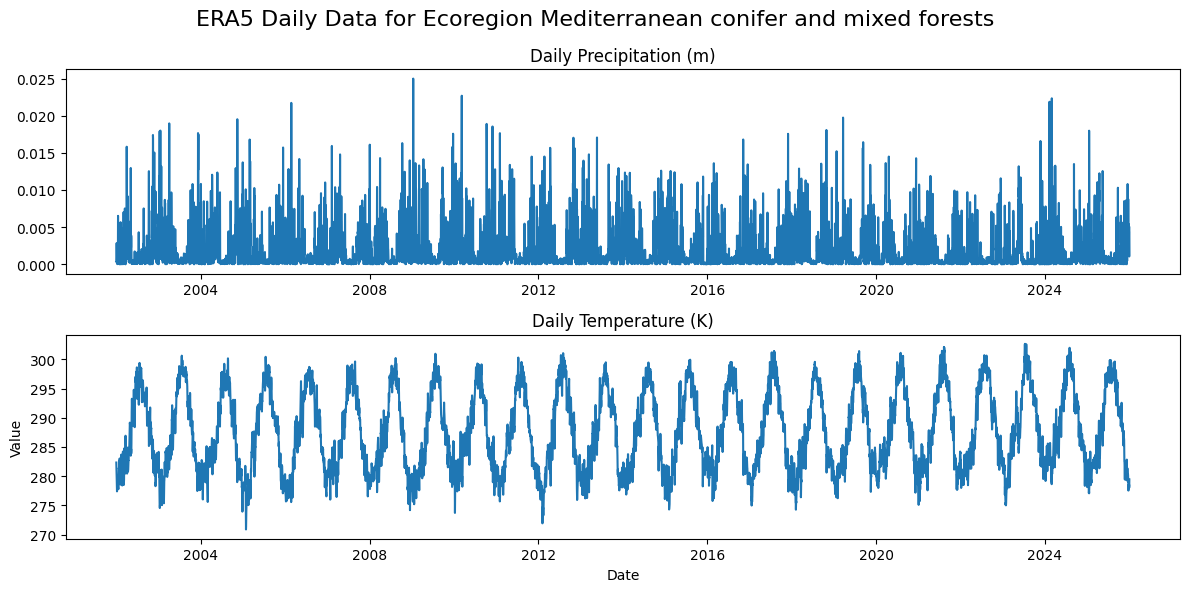

In [20]:
PLOT_ECO_ID = 701  # change this to inspect any ecoregion

matches = glob.glob(os.path.join(save_dir, f'ERA5_eco{PLOT_ECO_ID}_*.csv'))

if len(matches) == 0:
    print(f'No file found for eco_id {PLOT_ECO_ID}')
    raise SystemExit
    
plot_path = matches[0]
print(f'Found: {os.path.basename(plot_path)}')

out = pd.read_csv(plot_path)

out["date"] = pd.to_datetime(out["date"])


plt.figure(figsize=(12, 6))
plt.suptitle(f'ERA5 Daily Data for Ecoregion {out['eco_name'].iloc[0]}', fontsize=16)
plt.subplot(2, 1, 1)
plt.plot(out["date"], out["precip_m"])
plt.title("Daily Precipitation (m)")
plt.subplot(2, 1, 2)
plt.plot(out["date"], out["temperature_K"])
plt.title("Daily Temperature (K)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()
plt.show()
